# Leakage-free fixed-split model results

MAE, RMSE, and R² on the fixed artist/album-isolated held-out split. Neural-network values come from the fixed `evaluate_nn_models` run and traditional-model values come from their fixed, non-legacy notebooks. Lower MAE/RMSE and higher R² are better.

In [75]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# Leakage-free held-out results reported in the project outputs.
# Neural models: logs/evaluation/test_NN_models_fixed.6944064.qlog
# Traditional models: each model's fixed, non-legacy notebook test output.
results = [
    {"Model": "CNN",            "MAE": 11.4900, "RMSE": 14.4080, "R²":  0.0041},
    {"Model": "CNN-LSTM",       "MAE": 11.5140, "RMSE": 14.3450, "R²":  0.0129},
    {"Model": "LSTM",           "MAE": 11.9690, "RMSE": 14.8990, "R²": -0.0649},
    {"Model": "ResNet",         "MAE": 11.4270, "RMSE": 14.4830, "R²": -0.0062},
    {"Model": "ViT",            "MAE": 11.2940, "RMSE": 14.1110, "R²":  0.0449},
    {"Model": "Audio RF",       "MAE": 12.0235, "RMSE": 14.9979, "R²": -0.0784},
    {"Model": "Audio XGBoost",  "MAE": 11.7619, "RMSE": 14.7000, "R²": -0.0360},
    {"Model": "Lyrics RF",       "MAE": 10.6014, "RMSE": 13.6698, "R²":  0.0956},
    {"Model": "Artist XGBoost", "MAE":  6.3161, "RMSE":  8.2979, "R²":  0.6938},
    {"Model": "Hybrid: With Artist",    "MAE":  6.2387, "RMSE":  8.2253, "R²":  0.6658},
    {"Model": "Hybrid: Without Artist", "MAE": 10.2489, "RMSE": 12.9467, "R²":  0.1843},
]
results

[{'Model': 'CNN', 'MAE': 11.49, 'RMSE': 14.408, 'R²': 0.0041},
 {'Model': 'CNN-LSTM', 'MAE': 11.514, 'RMSE': 14.345, 'R²': 0.0129},
 {'Model': 'LSTM', 'MAE': 11.969, 'RMSE': 14.899, 'R²': -0.0649},
 {'Model': 'ResNet', 'MAE': 11.427, 'RMSE': 14.483, 'R²': -0.0062},
 {'Model': 'ViT', 'MAE': 11.294, 'RMSE': 14.111, 'R²': 0.0449},
 {'Model': 'Audio RF', 'MAE': 12.0235, 'RMSE': 14.9979, 'R²': -0.0784},
 {'Model': 'Audio XGBoost', 'MAE': 11.7619, 'RMSE': 14.7, 'R²': -0.036},
 {'Model': 'Lyrics RF', 'MAE': 10.6014, 'RMSE': 13.6698, 'R²': 0.0956},
 {'Model': 'Artist XGBoost', 'MAE': 6.3161, 'RMSE': 8.2979, 'R²': 0.6938},
 {'Model': 'Hybrid: With Artist', 'MAE': 6.2387, 'RMSE': 8.2253, 'R²': 0.6658},
 {'Model': 'Hybrid: Without Artist',
  'MAE': 10.2489,
  'RMSE': 12.9467,
  'R²': 0.1843}]

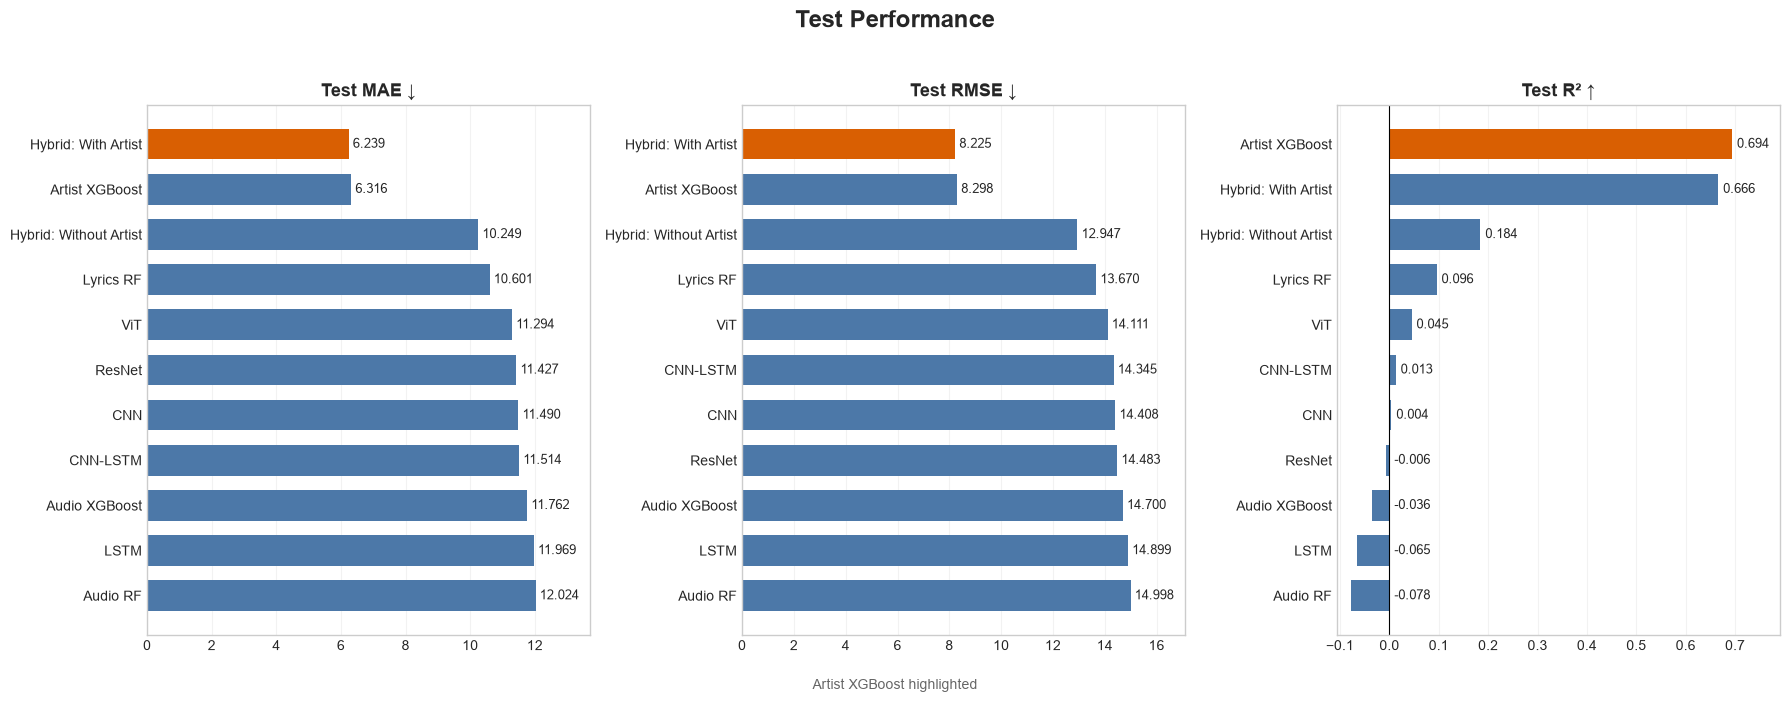

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (metric, title) in zip(
    axes,
    (("MAE", "Test MAE ↓"), ("RMSE", "Test RMSE ↓"), ("R²", "Test R² ↑")),
):
    available = [row for row in results if row[metric] is not None]
    ordered = sorted(available, key=lambda row: row[metric], reverse=(metric == "R²"))
    panel_models = [row["Model"] for row in ordered]
    values = [row[metric] for row in ordered]
    colors = ["#d95f02" if index == 0 else "#4c78a8" for index in range(len(ordered))]
    bars = ax.barh(panel_models, values, color=colors, height=0.68)
    ax.invert_yaxis()
    if metric == "R²":
        for bar, value in zip(bars, values):
            x = value + 0.01 if value >= 0 else 0.01
            ax.text(x, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=9)
    else:
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
        ax.set_xlim(0, max(values) * 1.14)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)
    if metric == "R²":
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlim(min(0, min(values) * 1.35), max(values) * 1.14)

fig.suptitle("Test Performance", fontsize=17, fontweight="bold")
fig.text(0.5, 0.01, "Artist XGBoost highlighted", ha="center", color="#666666")
fig.tight_layout(rect=(0, 0.04, 1, 0.95))
plt.show()

## Test metrics table

In [77]:
table_results = sorted(
    results,
    key=lambda row: row["R²"] if row["R²"] is not None else float("-inf"),
    reverse=True,
)
metrics_table = pd.DataFrame(table_results).rename(
    columns={"MAE": "Test MAE", "RMSE": "Test RMSE", "R²": "Test R²"}
).reset_index(drop=True)
metrics_table.index = metrics_table.index + 1

def bold_best(column):
    best = column.max() if column.name == "Test R²" else column.min()
    return ["font-weight: bold" if value == best else "" for value in column]

metrics_table.style.format(
    {"Test MAE": "{:.3f}", "Test RMSE": "{:.3f}", "Test R²": "{:.3f}"},
    na_rep="N/A",
).apply(
    bold_best,
    subset=["Test MAE", "Test RMSE", "Test R²"],
    axis=0,
).set_caption("Leakage-Free Fixed-Split Test Metrics")

,Model,Test MAE,Test RMSE,Test R²
1,Artist XGBoost,6.316,8.298,0.694
2,Hybrid: With Artist,6.239,8.225,0.666
3,Hybrid: Without Artist,10.249,12.947,0.184
4,Lyrics RF,10.601,13.670,0.096
5,ViT,11.294,14.111,0.045
6,CNN-LSTM,11.514,14.345,0.013
7,CNN,11.490,14.408,0.004
8,ResNet,11.427,14.483,-0.006
9,Audio XGBoost,11.762,14.700,-0.036
10,LSTM,11.969,14.899,-0.065


## Artist-inclusive convex blend coefficients

All candidate models are shown, including those assigned zero weight by the validation-selected convex blend.

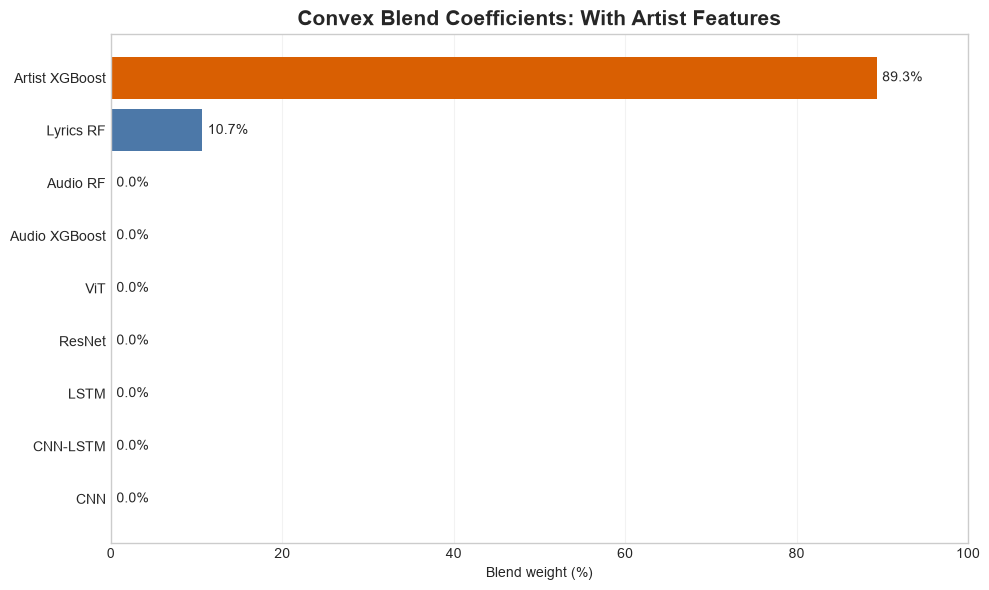

In [78]:
# models/hybrid/late_stage_fusion/artist/hybrid_artist.metrics.json
blend_weights = {
    "CNN": 0.0,
    "CNN-LSTM": 0.0,
    "LSTM": 0.0,
    "ResNet": 0.0,
    "ViT": 0.0,
    "Audio XGBoost": 0.0,
    "Audio RF": 0.0,
    "Lyrics RF": 0.1066,
    "Artist XGBoost": 0.8934,
}

fig_blend, ax = plt.subplots(figsize=(10, 6))
names = list(blend_weights)
percentages = [100 * blend_weights[name] for name in names]
blend_colors = ["#d95f02" if name == "Artist XGBoost" else "#4c78a8" for name in names]
bars = ax.barh(names, percentages, color=blend_colors)
ax.bar_label(bars, labels=[f"{value:.1f}%" for value in percentages], padding=4)
ax.set_title("Convex Blend Coefficients: With Artist Features", fontsize=15, fontweight="bold")
ax.set_xlabel("Blend weight (%)")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
fig_blend.tight_layout()
plt.show()

## No-artist convex blend coefficients

Fixed-split convex coefficients when artist features are excluded. Numerical optimization values smaller than `1e-10` are displayed as zero.

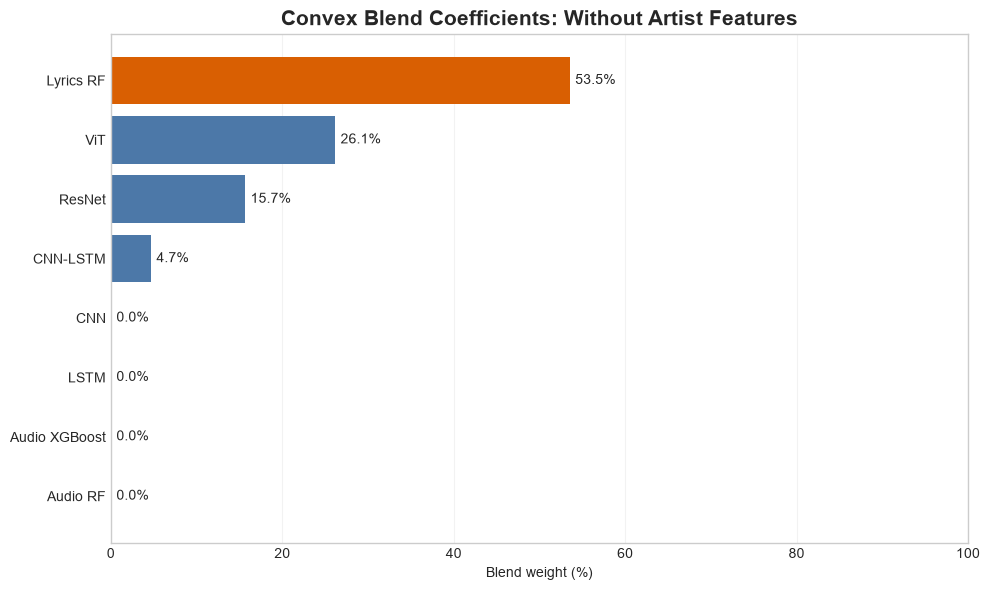

In [79]:
# models/hybrid/late_stage_fusion/no_artist/hybrid_no_artist.metrics.json
no_artist_blend_weights = {
    "CNN": 0.0,
    "CNN-LSTM": 0.0466893269,
    "LSTM": 0.0,
    "ResNet": 0.1565200041,
    "ViT": 0.2614795725,
    "Audio XGBoost": 0.0,
    "Audio RF": 0.0,
    "Lyrics RF": 0.5353110966,
}

fig_no_artist, ax = plt.subplots(figsize=(10, 6))
no_artist_names = sorted(no_artist_blend_weights, key=no_artist_blend_weights.get, reverse=True)
no_artist_percentages = [100 * no_artist_blend_weights[name] for name in no_artist_names]
no_artist_colors = ["#d95f02" if index == 0 else "#4c78a8" for index in range(len(no_artist_names))]
bars = ax.barh(no_artist_names, no_artist_percentages, color=no_artist_colors)
ax.invert_yaxis()
ax.bar_label(bars, labels=[f"{value:.1f}%" for value in no_artist_percentages], padding=4)
ax.set_title("Convex Blend Coefficients: Without Artist Features", fontsize=15, fontweight="bold")
ax.set_xlabel("Blend weight (%)")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
fig_no_artist.tight_layout()
plt.show()

In [80]:
# Optional high-resolution exports for the abstract/poster.
repo_root = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "figures").is_dir()), Path.cwd())
output_path = repo_root / "figures" / "best_model_results.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
blend_output_path = repo_root / "figures" / "artist_convex_blend_coefficients.png"
fig_blend.savefig(blend_output_path, dpi=300, bbox_inches="tight")
no_artist_blend_output_path = repo_root / "figures" / "no_artist_convex_blend_coefficients.png"
fig_no_artist.savefig(no_artist_blend_output_path, dpi=300, bbox_inches="tight")
table_csv_path = repo_root / "figures" / "test_metrics_table.csv"
metrics_table.to_csv(table_csv_path, index=False, na_rep="N/A")
output_path, blend_output_path, no_artist_blend_output_path, table_csv_path

(PosixPath('/Users/lucaslu/Lucas/Code Repositories/bu-rise-music/figures/best_model_results.png'),
 PosixPath('/Users/lucaslu/Lucas/Code Repositories/bu-rise-music/figures/artist_convex_blend_coefficients.png'),
 PosixPath('/Users/lucaslu/Lucas/Code Repositories/bu-rise-music/figures/no_artist_convex_blend_coefficients.png'),
 PosixPath('/Users/lucaslu/Lucas/Code Repositories/bu-rise-music/figures/test_metrics_table.csv'))